In [1]:
using CloudAtlas
using DifferentialEquations
using LinearAlgebra
using Plots
using CairoMakie

[ Info: Precompiling CloudAtlas [b31a9ccd-01a9-4409-bcc3-9c4abd24a9a3] (cache misses: include_dependency fsize change (2), mismatched flags (6))
[ Info: Precompiling CloudAtlasDiffEqExt [e769e89b-5572-5e4c-8d10-9139b6527533] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling CloudAtlasVisualizationExt [91dd8eae-e5c9-5f98-bbaa-dfe67aeb58cb] (cache misses: wrong dep version loaded (2))


In [2]:
sx, sy, sz, tx, tz = halfbox_symmetries()
α, γ = 2π/4.0, 2π/6.0 
J, K, L = 2, 2, 3
H = [sz*tx]
model = TWModel(α, γ, J, K, L, H, normalize=true)
m = length(model)

J,K,L,m == 2,2,3,88
(2J+1)(2K+1)(2L+1) + 1 == 176
Making matrices B, A1, A2, Cx, Cz...
Phase constraints: keep_cx = true, keep_cz = false
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 


88

In [3]:
R_target = 400.0
f(ξ) = model.g(ξ, R_target)
Df(ξ) = model.Dg(ξ, R_target)
xnorm = 0.40
ξ_guess = zeros(m + 2)
ξ_star = ξ_guess;

In [4]:
while true
    x_guess = randn(m)
    x_guess = xnorm/norm(x_guess) * x_guess
    cx_guess = randn() * 0.1
    cz_guess = 0
    ξ_guess = [x_guess; cx_guess; cz_guess]
    params = SearchParams(ftol=1e-6, xtol=1e-6, Nnewton=30, Nhook=8, verbosity=0)
    ξ_star, converged = hookstepsolve(f, Df, ξ_guess, params)
    print(".")
    if converged && norm(ξ_star[1:m]) > 1e-3 && ξ_star[end - 1] > 1e-1
        println("\nConverged:", converged)
        break
    end
end

..............
Converged:true


In [5]:
norm(ξ_star[1:m]), ξ_star[end - 1 ], ξ_star[end]

(0.2466617320764552, 0.2971093301730168, 0.0)

In [10]:
sol = integrate_flow(model, ξ_star, (0.0, 10.0), saveat = 0.1, lab_frame = false);

The traveling wave cx term is: cx*Cx*x = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0009078935371378661, -0.006471849637049538, 0.0016936855691530664, 0.00737493375767119, -0.008751385109344475, -0.0009796013417921608, -0.010147949632454564, 0.005505642179718482, -0.005041877217059202, 0.006642563257551648, 0.0007867996912189574, -0.009419787247523799, -0.004315192239135847, -0.005396408932817827, 0.004527280210926836, -0.004770501221707469, -0.0025342164895313856, 0.0064218948841630215, -0.004426484142141247, -0.002867750826023441, -0.0043411504251123015, 0.004657300144955771, -0.007663674928060804, -0.0032319793584684314, -0.006112306286915298, 0.0055002093986774355, -0.0023247315506921195, 0.0029276499717096026, 0.0006963493819282378, -0.003805063083937415, -0.006264184074582789, -0.0007222980234279652, 0.006346826514448398, 0.00459092194347208, -0.0028824981476083217, -0.002594685138528624, 0.00042410872347407196, 0.001775476533731

Building dissipation matrix...


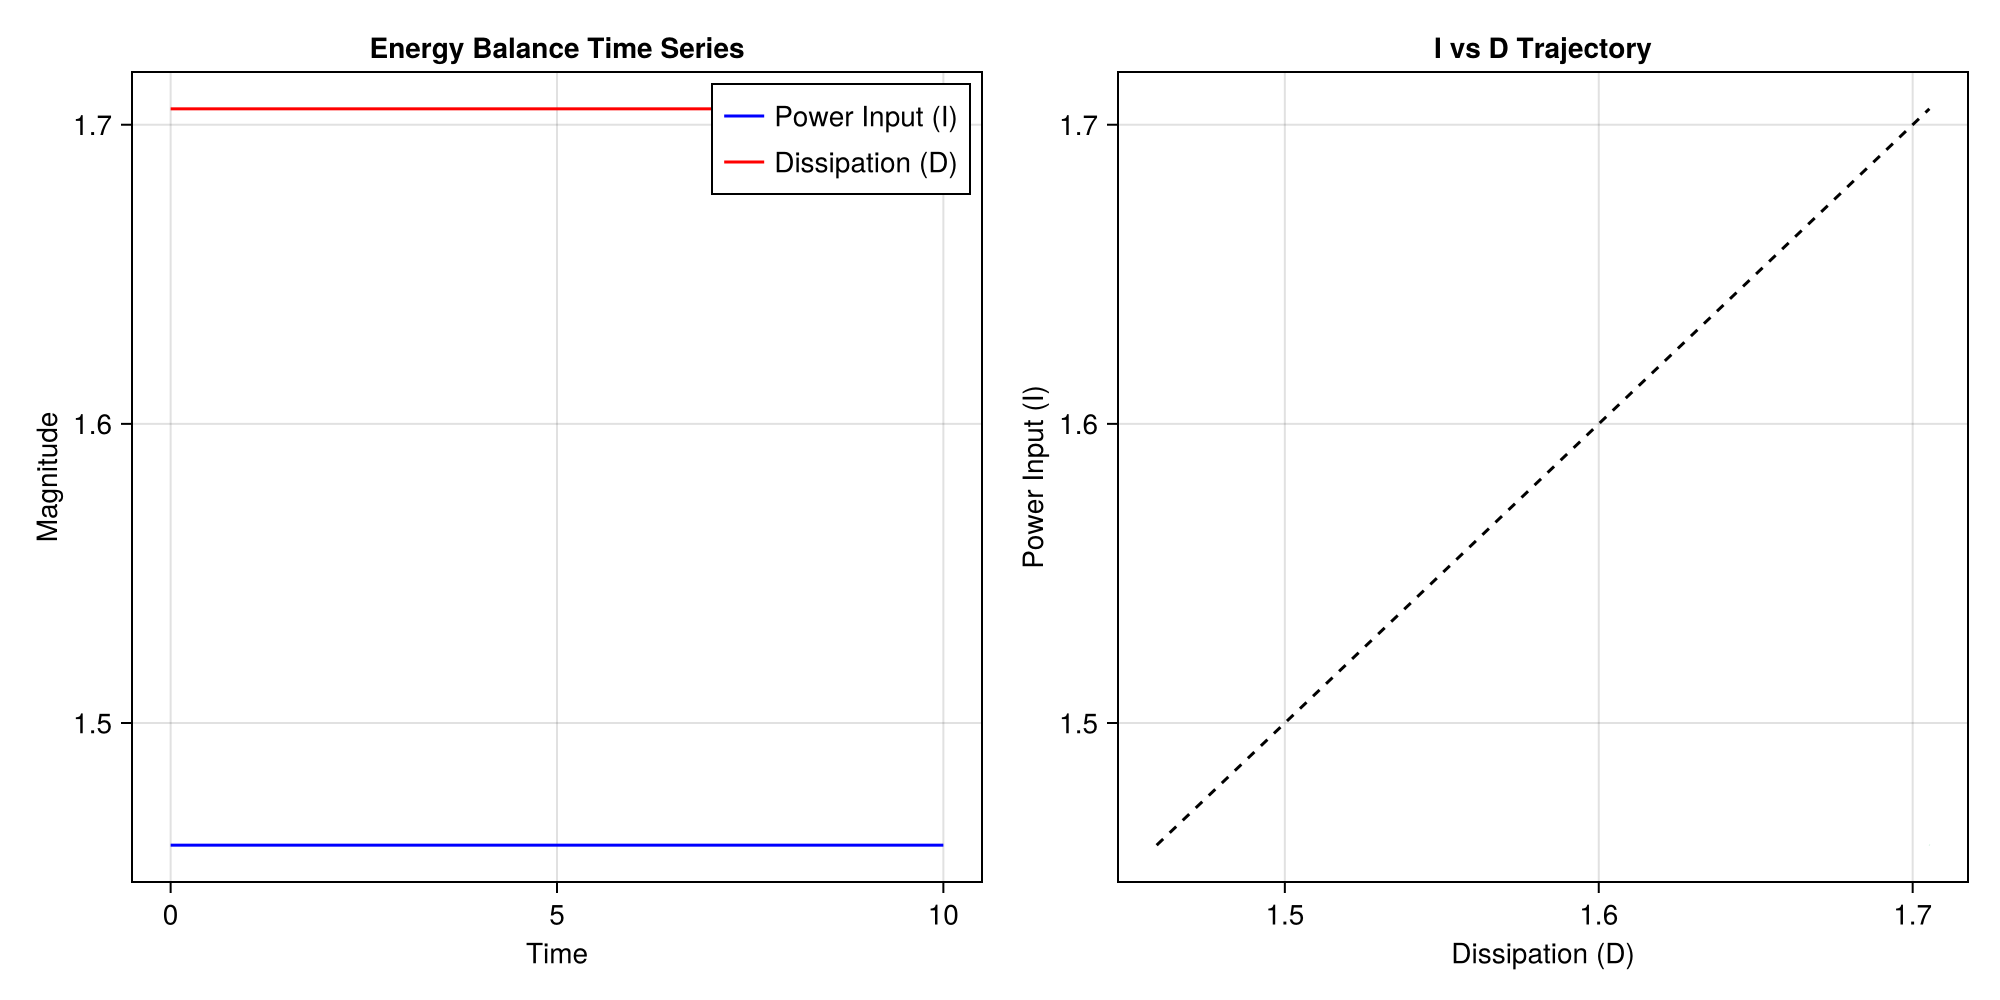

In [7]:
D_matrix = build_dissipation_matrix(model)
plot_id_series(model, sol, D_matrix)

In [8]:
# animate_flow(model, sol, "traveling_wave_fastx.mp4"; add_baseflow=true )

In [9]:

# # --- 2. Setup Plotting ---
# Lx=2π/model.α
# Lz=2π/model.γ

# settings = PlotSettings()
# fig = Figure(size=settings.fig_size)
# # XZ plane: mean (u, w) averaged over y
# ax_xz = Axis(fig[1, 1],
#     title="Mean (u, w) in xz-plane",
#     xlabel="X", ylabel="Z", limits = (0, Lx, 0, Lz))

# # XY plane: (u, v) at z = 0
# ax_xy = Axis(fig[2, 1],
#     title="(u, v) in xy-plane at z = 0",
#     xlabel="X", ylabel="Y", limits = (0, Lx, -1, 1))

# # YZ plane: (v, w) at x = 0 with u heatmap
# ax_yz = Axis(fig[3, 1],
#     title="(v, w) in yz-plane at x = 0",
#     xlabel="Z", ylabel="Y",
#     aspect=DataAspect(), limits = (0, Lz, -1, 1))

# Colorbar(fig[3, 2], 
#          colormap=settings.colormap,
#          limits=(-1, 1),
#          label="Streamwise velocity u")

# # --- 3. Generate Animation ---

# # Define time range and stride (frame skipping) for the animation
# # Assuming 'sol' is your DifferentialEquations solution
# frames = 1:2:length(sol.t) 
# # frames = 1:2:5

# println("Rendering animation with $(length(frames)) frames...")

# record(fig, "traveling_wave_evolution.mp4", frames; framerate=15) do i
#     t = sol.t[i]
#     x_state = sol.u[i]
    
#     # Update the title with current time
#     ax_xz.title = "XZ Plane - t = $(round(t, digits=2))"
    
#     # 1. Construct VelocityField for current state
#     #    Set add_baseflow=true to see the physical flow, or false to see just perturbations
#     vf = VelocityField(model, x_state; add_baseflow=false) 
    
#     # 2. Clear previous arrows/heatmaps
#     empty!(ax_xz)
#     empty!(ax_xy)
#     empty!(ax_yz)
    
#     # 3. Plot new frame using your utilities
#     #    Note: We pass the axes we created above
#     plot_xz_plane!(ax_xz, vf, settings, Lx=2π/model.α, Lz=2π/model.γ, y_slice=:mean)
#     plot_xy_plane!(ax_xy, vf, settings, Lx=2π/model.α, z_slice=0.0)
#     plot_yz_plane!(ax_yz, vf, settings, Lz=2π/model.γ, x_slice=0.0)
# end

# println("Animation saved: traveling_wave_evolution.mp4")